Профессия Data Science  
Блок 6. Математика в ML. Часть II  
**MATH&ML-9. Математика ансамблевых методов**

---

## **✍ Оглавление:**

1. Введение
2. Ансамбли моделей. Бутстреппинг. Бэггинг
3. Случайный лес
4. Случайный лес. Практика
5. Бустинг
6. Бустинг. Практика

## **1. Введение**

**Ансамбль моделей** — это метод, в котором несколько алгоритмов (или вариации одного и того же) обучаются на одних данных, а итоговый прогноз строится на основе всех полученных от моделей прогнозов.

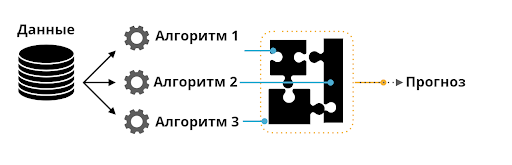

## **2. Ансамбли моделей. Бутстреппинг. Бэггинг**

В основе бэггинга лежит статистический метод, который называется **бутстрепом (bootstrap)**. Идея бутстрепа заключается в генерации выборок размера n из исходного датасета размера N путём случайного выбора элементов с повторениями в каждом из наблюдений.

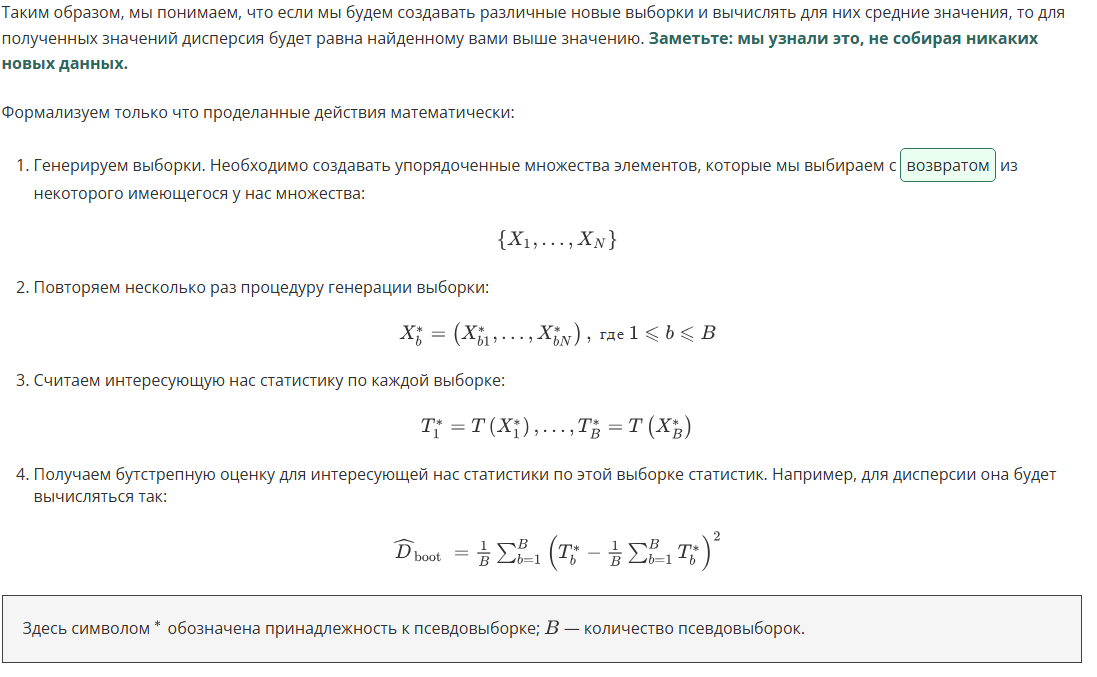

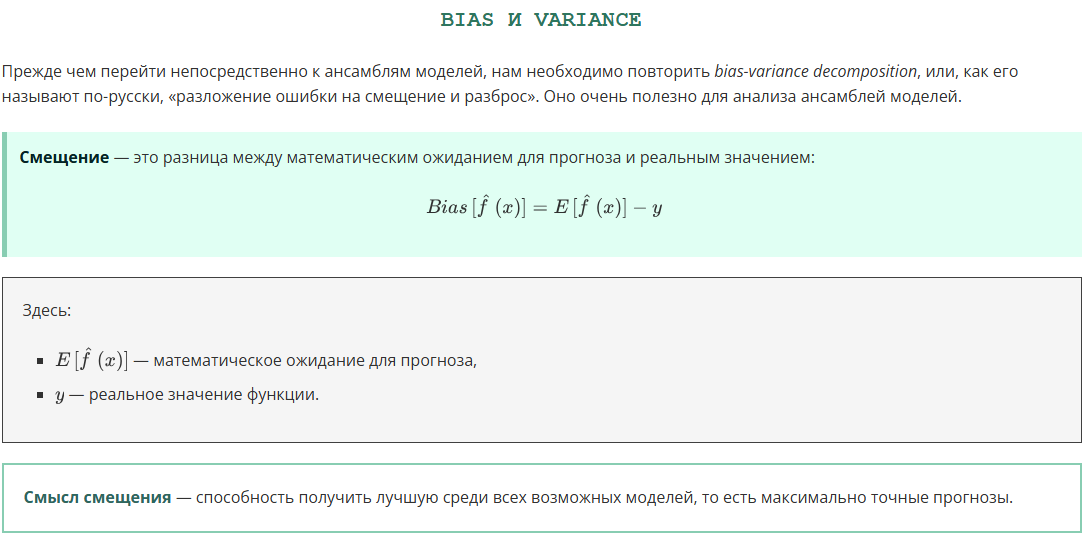

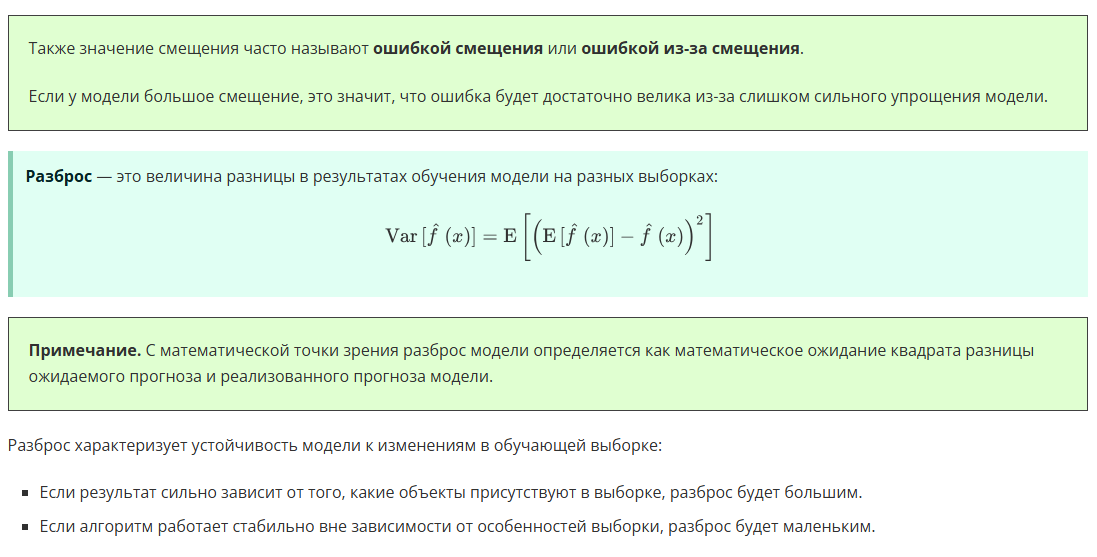

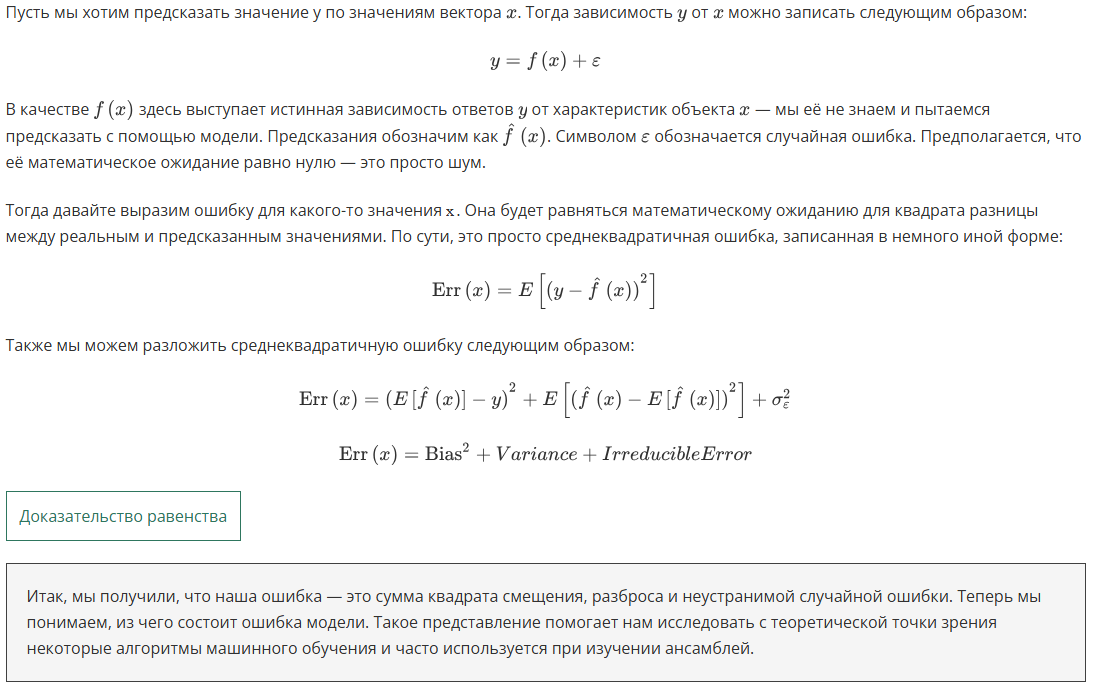

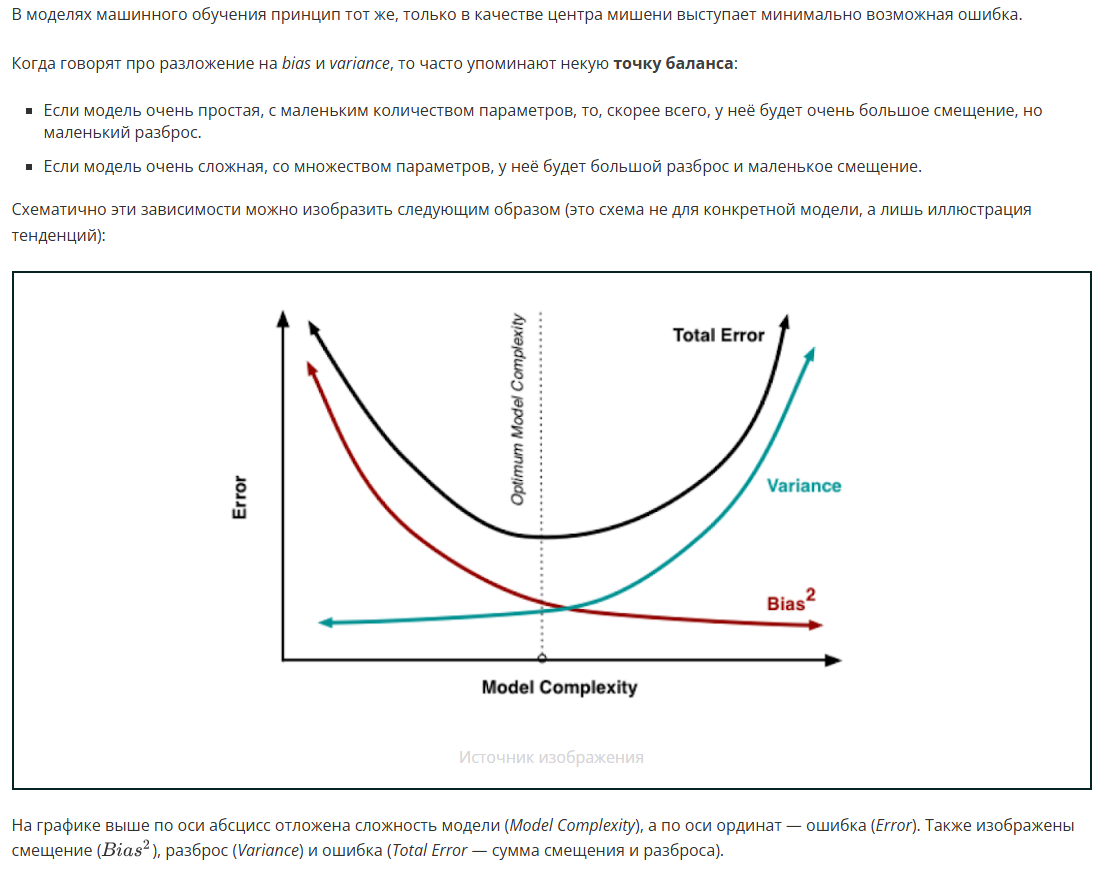

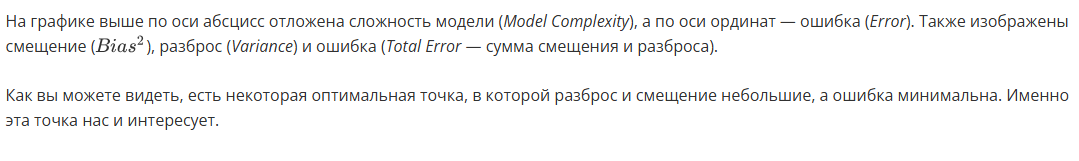

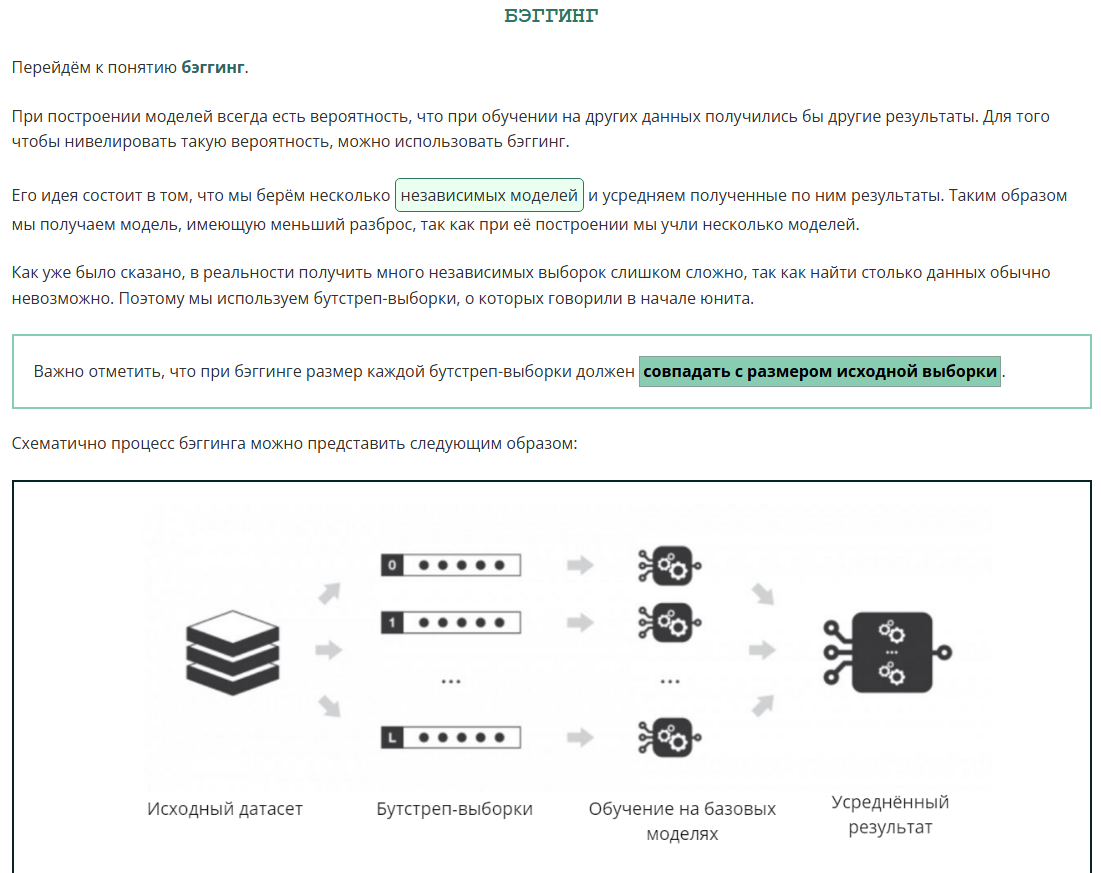

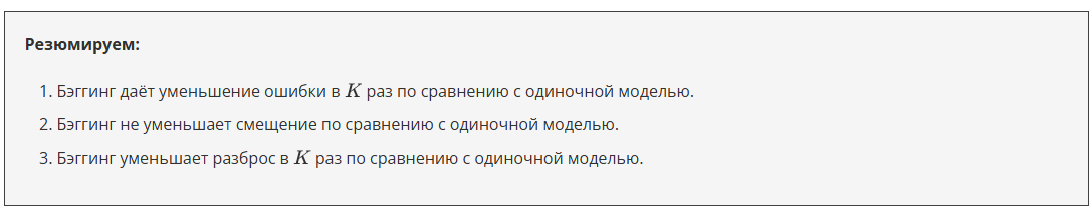

## **3. Случайный лес**

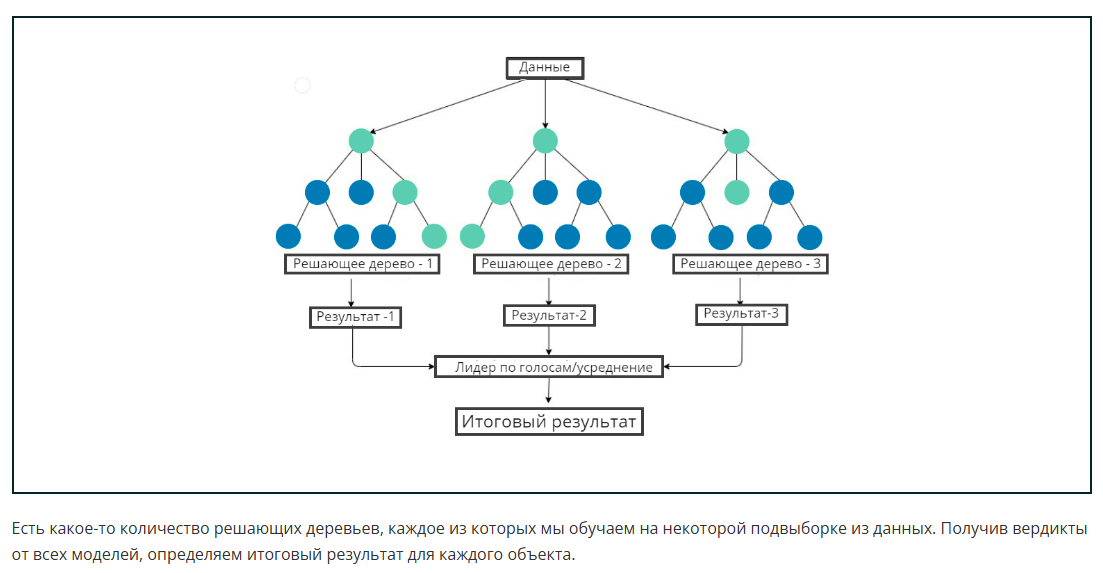

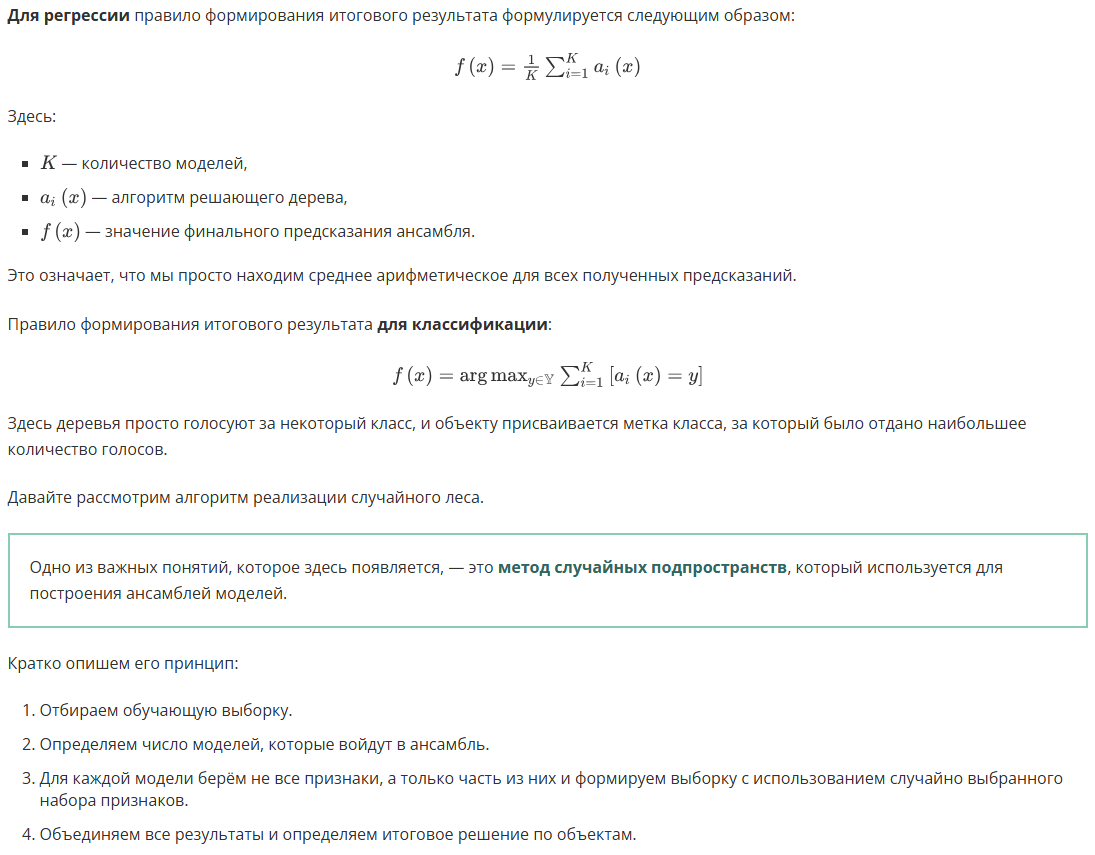

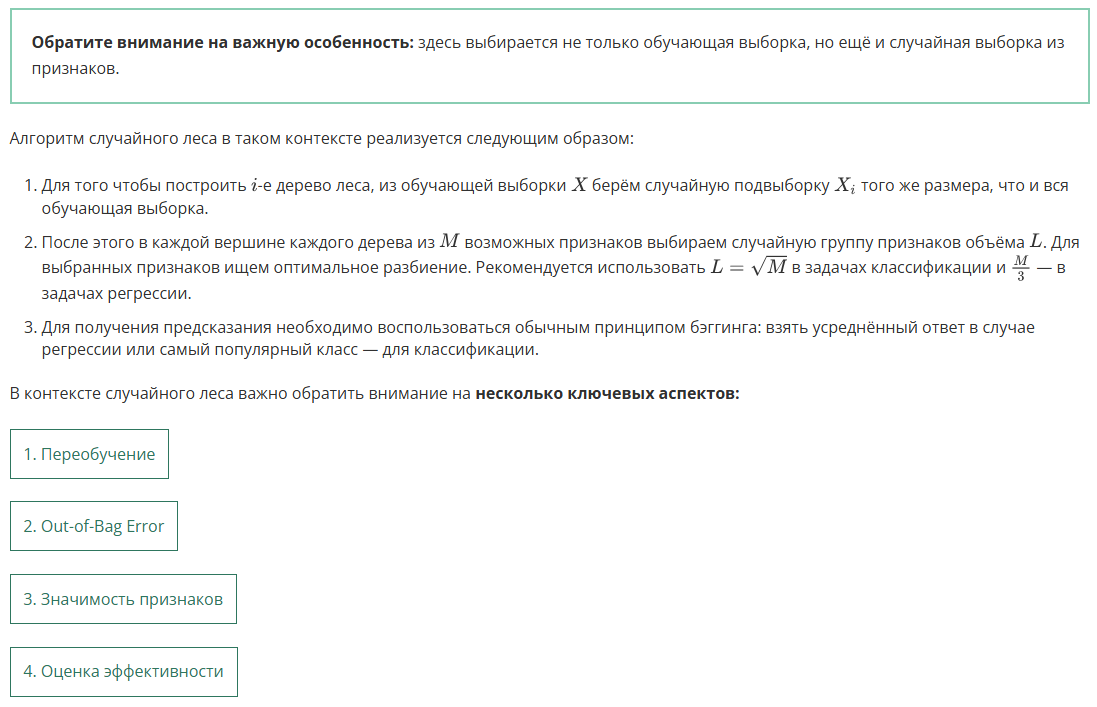

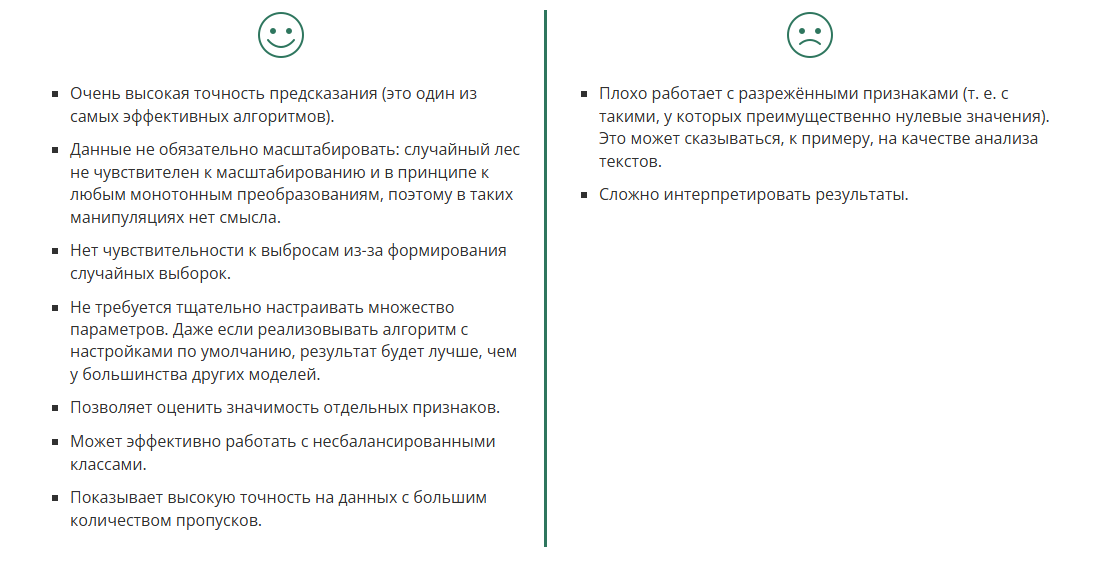

## **4. Случайный лес. Практика**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0)

# Загружаем исходные данные:
df = pd.read_csv('weatherAUS.csv')
df.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [2]:
# Задание 4.1

df.isnull().sum().sum()

343248

In [3]:
# Задание 4.2

round(df.isna().sum() / len(df), 3)
df.drop(['Evaporation','Sunshine','Cloud3pm'], axis = 1, inplace = True)

In [4]:
# Задание 4.3

df.RainToday = df.RainToday.map({'No': 0, 'Yes': 1})
df.RainTomorrow = df.RainTomorrow.map({'No': 0, 'Yes': 1})
print(round((df.RainToday).mean(), 2))

0.22


In [5]:
# Задание 4.4

df.Date = pd.to_datetime(df.Date)
df['Month'] = df.Date.dt.month
df.drop('Date', axis = 1, inplace = True)
df_season = df.groupby('Month').mean(numeric_only=True)
df_season[['RainToday']]

,RainToday
Month,
1,0.189484
2,0.206746
3,0.217135
4,0.216845
5,0.222163
6,0.263638
7,0.270736
8,0.253167
9,0.229135


In [6]:
# Задание 4.5

categoricals = ['Month', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
df_dummies = pd.get_dummies(df, columns=categoricals)
df_dummies.shape

(145460, 124)

In [7]:
# Задание 4.6

df_dummies.dropna(inplace=True)
X = df_dummies.drop('RainTomorrow', axis = 1)
Y = df_dummies['RainTomorrow']  
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state = 31)
Y_test.mean()

0.22770253002811142

In [8]:
# Задание 4.7

def gbs(data, n):     
    inds = np.random.randint(0, len(data), (n, len(data))) #определяем индексы случайным образом
    numbers = data[inds] #выбираем значения по индексам
    return numbers
target = X_train['MinTemp'].values #выбираем целевую переменную
np.random.seed(31) #задаём параметр генератора случайных чисел
mean_values = [np.mean(x) for x in gbs(target, 1000)] #получаем все средние значения
np.std(mean_values) #находим для них стандартное отклонение

0.02879072820657669

In [9]:
# Задание 4.8

clf = LogisticRegression()
clf.fit(X_train, Y_train)
preds_train = clf.predict(X_train)
preds_test = clf.predict(X_test)
roc_auc_score(Y_test, preds_test)

c:\Users\IK\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7274138237536282

In [10]:
# Задание 4.9

params = {
    'max_leaf_nodes': list(range(2, 10)), 
    'min_samples_split': [2, 3, 4], 
    'max_depth': [5,7,9,11]
}

grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), params, verbose=3, cv=3)
grid_search_cv.fit(X_train, Y_train)
print(grid_search_cv.best_params_)

clf = DecisionTreeClassifier(max_depth = 5, max_leaf_nodes = 9, min_samples_split = 2, random_state=42)
clf.fit(X_train, Y_train)
preds_train = clf.predict(X_train)
preds_test = clf.predict(X_test)
print(round(roc_auc_score(Y_test, preds_test), 2))

Fitting 3 folds for each of 96 candidates, totalling 288 fits
[CV 1/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=2;, score=0.817 total time=   0.1s
[CV 2/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=2;, score=0.820 total time=   0.0s
[CV 3/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=2;, score=0.825 total time=   0.0s
[CV 1/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=3;, score=0.817 total time=   0.1s
[CV 2/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=3;, score=0.820 total time=   0.1s
[CV 3/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=3;, score=0.825 total time=   0.0s
[CV 1/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=4;, score=0.817 total time=   0.0s
[CV 2/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=4;, score=0.820 total time=   0.0s
[CV 3/3] END max_depth=5, max_leaf_nodes=2, min_samples_split=4;, score=0.825 total time=   0.1s
[CV 1/3] END max_depth=5, max_leaf_nodes=3, min_samples_split=2;,

In [11]:
# Задание 4.10

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf = RandomForestClassifier(n_estimators = 100, random_state=31)
clf.fit(X_train, Y_train)
preds_train = clf.predict(X_train)
preds_test = clf.predict(X_test)
print(round(roc_auc_score(Y_test, preds_test), 2))

0.73


In [12]:
# Задание 4.11

params = {
    'max_features': [4, 5, 6, 7], 
    'min_samples_leaf': [3, 5, 7, 9, 11], 
    'max_depth': [5, 10, 15]
}
grid_search_cv = GridSearchCV(RandomForestClassifier(random_state=31), params, verbose=3, cv=3)
grid_search_cv.fit(X_train, Y_train)
print(grid_search_cv.best_params_)
clf = RandomForestClassifier(n_estimators = 100, max_depth=15, max_features=7, min_samples_leaf=3, random_state=31)
clf.fit(X_train, Y_train)
preds_train = clf.predict(X_train)
preds_test = clf.predict(X_test)
print(round(roc_auc_score(Y_test, preds_test), 2))

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV 1/3] END max_depth=5, max_features=4, min_samples_leaf=3;, score=0.776 total time=   1.1s
[CV 2/3] END max_depth=5, max_features=4, min_samples_leaf=3;, score=0.775 total time=   1.3s
[CV 3/3] END max_depth=5, max_features=4, min_samples_leaf=3;, score=0.775 total time=   1.1s
[CV 1/3] END max_depth=5, max_features=4, min_samples_leaf=5;, score=0.776 total time=   1.0s
[CV 2/3] END max_depth=5, max_features=4, min_samples_leaf=5;, score=0.775 total time=   1.1s
[CV 3/3] END max_depth=5, max_features=4, min_samples_leaf=5;, score=0.775 total time=   1.1s
[CV 1/3] END max_depth=5, max_features=4, min_samples_leaf=7;, score=0.776 total time=   1.2s
[CV 2/3] END max_depth=5, max_features=4, min_samples_leaf=7;, score=0.775 total time=   1.1s
[CV 3/3] END max_depth=5, max_features=4, min_samples_leaf=7;, score=0.775 total time=   1.2s
[CV 1/3] END max_depth=5, max_features=4, min_samples_leaf=9;, score=0.776 total time=   1.3

In [13]:
# Задание 4.12

feature_names = [x for x in df_dummies if x != 'RainTomorrow']
pd.DataFrame({'feat': feature_names,
              'coef': clf.feature_importances_}).sort_values(by='coef', ascending=False)

,feat,coef
7,Humidity3pm,0.250783
2,Rainfall,0.079757
6,Humidity9am,0.070403
10,Cloud9am,0.067092
9,Pressure3pm,0.065272
...,...,...
50,Location_Newcastle,0.000000
62,Location_SalmonGums,0.000000
51,Location_Nhil,0.000000
52,Location_NorahHead,0.000000


## **5. Бустинг**

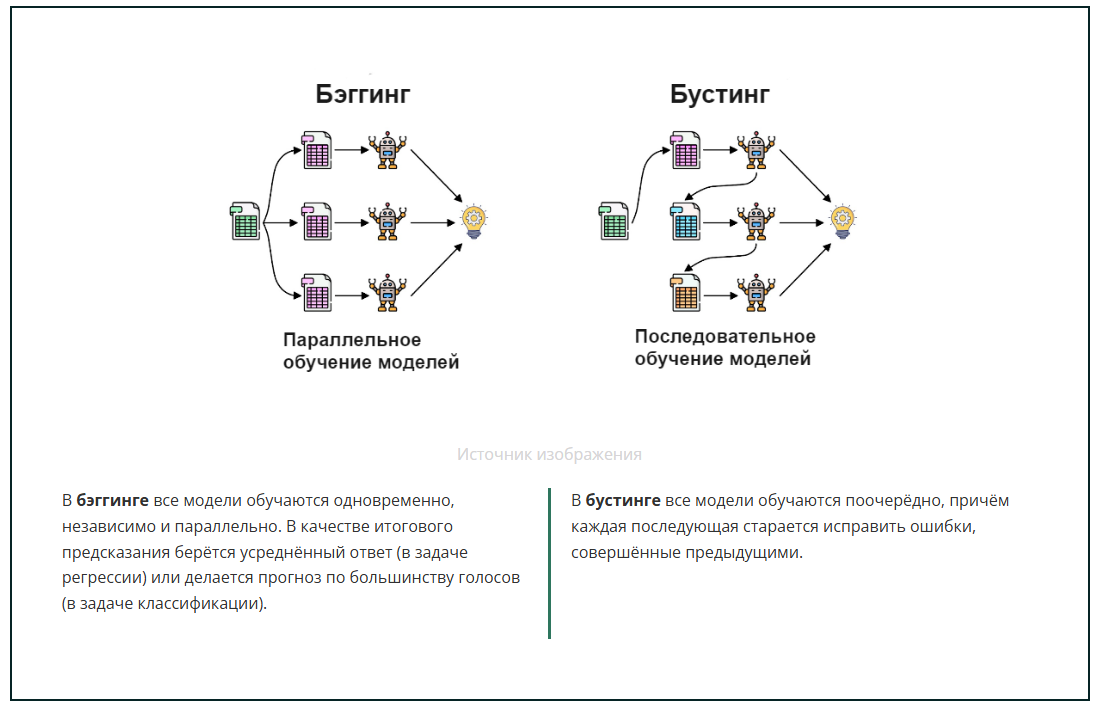

**<center> AdaBoost </center>**

Первый ансамбль типа бустинг, который мы рассмотрим, называется **AdaBoost (Adaptive Boosting)**.

**Бустинг** позволяет из большого количества относительно слабых и простых моделей получить одну сильную. В нашем случае будут рассматриваться деревья решений ограниченной глубины (всего из одного уровня) — их ещё называют **пнями**.

**<center> Градиентный бустинг </center>**

Переходим к следующему алгоритму, который очень популярен благодаря своей высокой эффективности, — к **градиентному бустингу**.

Принцип его работы аналогичен AdaBoost: следующие модели улучшают композицию построенных ранее.

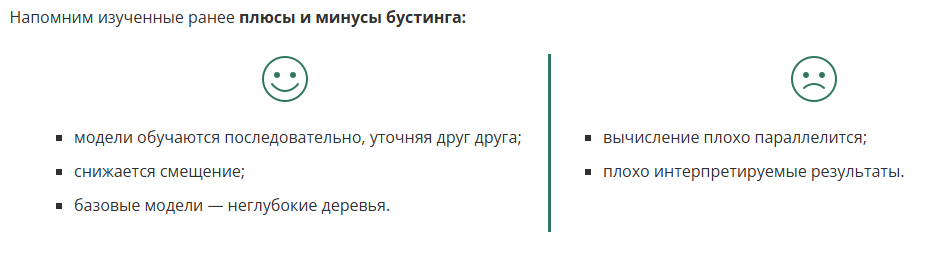

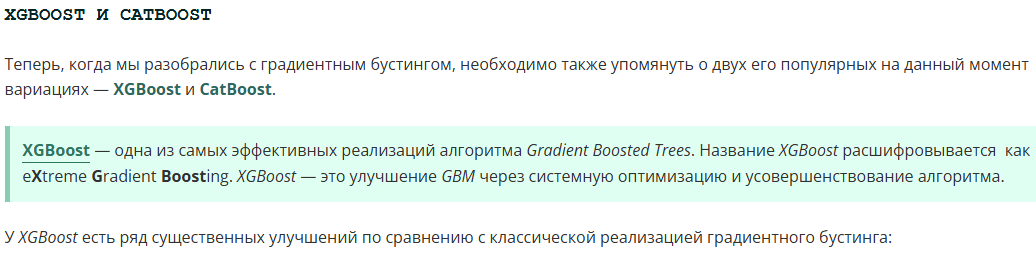

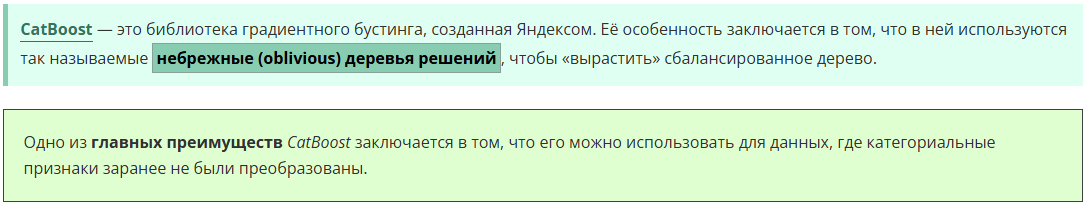

## **6. Бустинг. Практика**

In [14]:
# Загружаем исходные данные:
df = pd.read_csv('AirPass.csv')
df.head(3)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


In [15]:
df.isnull().sum().sum()

310

In [ ]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
df['Arrival Delay in Minutes'].mean()

In [16]:
# Задание 6.3

df.groupby('Gender')['satisfaction'].value_counts()*100/df.shape[0]
df.groupby('Type of Travel')['satisfaction'].value_counts()*100/df.shape[0]
df.groupby('Class')['satisfaction'].value_counts()*100/df.shape[0]

Class     satisfaction           
Business  satisfied                  33.184478
          neutral or dissatisfied    14.614452
Eco       neutral or dissatisfied    36.614567
          satisfied                   8.374076
Eco Plus  neutral or dissatisfied     5.437712
          satisfied                   1.774715
Name: count, dtype: float64

In [17]:
# Задание 6.4

df=pd.get_dummies(df)
df.shape

(103904, 31)

In [18]:
# Задание 6.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=26)
y_test.shape

NameError: name 'y' is not defined

In [19]:
# Задание 6.6

scaler = StandardScaler()
scaler.fit(X_train) 
X_train = scaler.transform(X_train) 
X_test = scaler.transform(X_test) 
X_test[0][0]

NameError: name 'StandardScaler' is not defined

In [ ]:
# Задание 6.7

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
preds_test = model_lr.predict(X_test)
f1_score(preds_test, y_test)

In [ ]:
# Задание 6.8

model_ada = AdaBoostClassifier(DecisionTreeClassifier(random_state=26),random_state=26,learning_rate=0.01)

model_ada.fit(X_train, y_train)
preds_test = model_ada.predict(X_test)
f1_score(preds_test, y_test)

In [ ]:
# Задание 6.9

model_for_gs = GradientBoostingClassifier()
params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}
gs = GridSearchCV(model_for_gs, 
                  params, 
                  cv=3, 
                  scoring=make_scorer(f1_score),
                  verbose=5)
 
gs.fit(X_train, y_train)
 
print("Лучшие гиперпараметры:", gs.best_params_)
print("Лучшее значение метрики:", gs.best_score_)

In [ ]:
# Задание 6.10

model_xgb = XGBClassifier(random_state=26)
model_xgb.fit(X_train,y_train)
preds_test = model_xgb.predict(X_test)
f1_score(preds_test, y_test)

In [ ]:
# Задание 6.11

model = CatBoostClassifier(random_state=26)
model.fit(X_train, y_train)
preds_class = model.predict(X_test)
f1_score(preds_class, y_test)

In [ ]:
# Задание 6.12

cm = get_confusion_matrix(model, Pool(X_train, y_train))

In [ ]:
# Задание 6.13

pd.DataFrame(
    {
        "feature_importance": clf.get_feature_importance(),
        "feature_names": df.drop(columns="satisfaction").columns,
    }
).sort_values(by=["feature_importance"], ascending=False)